In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas_datareader.data as web
import datetime

from functions import get_polymarket_event

In [2]:
june_event, june_probs = get_polymarket_event("fed-decision-in-june-825", "2026-06-17")
for name, df in june_probs.items():
    print(name, len(df), "points")

50+ bps decrease 240 points
25 bps decrease 240 points
No change 240 points
25 bps increase 240 points
50+ bps increase 240 points


In [3]:
start_june = datetime.datetime(2026, 5, 17)
end_june = datetime.datetime(2026, 6, 16)

effr_june = web.DataReader('EFFR', 'fred', start_june, end_june)
r_before_june = effr_june['EFFR'].mean()
print(r_before_june)

3.6214285714285714


In [4]:
combined_june = pd.DataFrame()
for outcome_name, odf in june_probs.items():
    s = odf.set_index('datetime')['p'].resample('1min').last().ffill()
    combined_june[outcome_name] = s

combined_june = combined_june.dropna()
print(combined_june.head())
print(combined_june.tail())

                           50+ bps decrease  25 bps decrease  No change  \
datetime                                                                  
2026-06-17 12:00:00-04:00            0.0005           0.0025     0.9975   
2026-06-17 12:01:00-04:00            0.0005           0.0025     0.9975   
2026-06-17 12:02:00-04:00            0.0005           0.0025     0.9975   
2026-06-17 12:03:00-04:00            0.0005           0.0025     0.9975   
2026-06-17 12:04:00-04:00            0.0005           0.0025     0.9975   

                           25 bps increase  50+ bps increase  
datetime                                                      
2026-06-17 12:00:00-04:00           0.0005            0.0005  
2026-06-17 12:01:00-04:00           0.0005            0.0005  
2026-06-17 12:02:00-04:00           0.0005            0.0005  
2026-06-17 12:03:00-04:00           0.0005            0.0005  
2026-06-17 12:04:00-04:00           0.0005            0.0005  
                           50+ bp

In [5]:
prob_sum_june = (
    combined_june['50+ bps decrease'] +
    combined_june['25 bps decrease'] +
    combined_june['No change'] +
    combined_june['25 bps increase'] +
    combined_june['50+ bps increase']
)

combined_june['r_after'] = (
    (combined_june['50+ bps decrease'] / prob_sum_june) * (r_before_june - 0.50) +
    (combined_june['25 bps decrease'] / prob_sum_june) * (r_before_june - 0.25) +
    (combined_june['No change'] / prob_sum_june) * r_before_june +
    (combined_june['25 bps increase'] / prob_sum_june) * (r_before_june + 0.25) +
    (combined_june['50+ bps increase'] / prob_sum_june) * (r_before_june + 0.50)
)

print(combined_june[['r_after']].head())
print(combined_june[['r_after']].tail())

                            r_after
datetime                           
2026-06-17 12:00:00-04:00  3.620929
2026-06-17 12:01:00-04:00  3.620929
2026-06-17 12:02:00-04:00  3.620929
2026-06-17 12:03:00-04:00  3.620929
2026-06-17 12:04:00-04:00  3.620929
                            r_after
datetime                           
2026-06-17 15:55:00-04:00  3.621429
2026-06-17 15:56:00-04:00  3.621429
2026-06-17 15:57:00-04:00  3.621429
2026-06-17 15:58:00-04:00  3.621429
2026-06-17 15:59:00-04:00  3.621429


In [6]:
zq_2026 = pd.read_csv('zq_2026.csv')
zq_2026['datetime'] = pd.to_datetime(zq_2026['time'], unit='s')
zq_2026['datetime'] = zq_2026['datetime'].dt.tz_localize('UTC').dt.tz_convert('America/New_York')

june_zq_window = zq_2026[(zq_2026['datetime'] >= '2026-06-17 12:00:00') & (zq_2026['datetime'] <= '2026-06-17 16:00:00')].copy()
june_zq_window['implied_rate'] = 100 - june_zq_window['close']
print(june_zq_window.head())
print(june_zq_window.tail())

             time    open    high     low   close  Volume  \
10521  1781712000  96.370  96.370  96.370  96.370       7   
10522  1781713140  96.365  96.365  96.365  96.365      60   
10523  1781713320  96.370  96.370  96.370  96.370       1   
10524  1781713380  96.370  96.370  96.370  96.370       1   
10525  1781713440  96.370  96.370  96.370  96.370       1   

                       datetime  implied_rate  
10521 2026-06-17 12:00:00-04:00         3.630  
10522 2026-06-17 12:19:00-04:00         3.635  
10523 2026-06-17 12:22:00-04:00         3.630  
10524 2026-06-17 12:23:00-04:00         3.630  
10525 2026-06-17 12:24:00-04:00         3.630  
             time    open    high     low   close  Volume  \
10641  1781726100  96.355  96.355  96.355  96.355      63   
10642  1781726220  96.355  96.355  96.355  96.355      20   
10643  1781726280  96.355  96.355  96.355  96.355      19   
10644  1781726340  96.355  96.355  96.355  96.355      32   
10645  1781726400  96.355  96.355  96.35

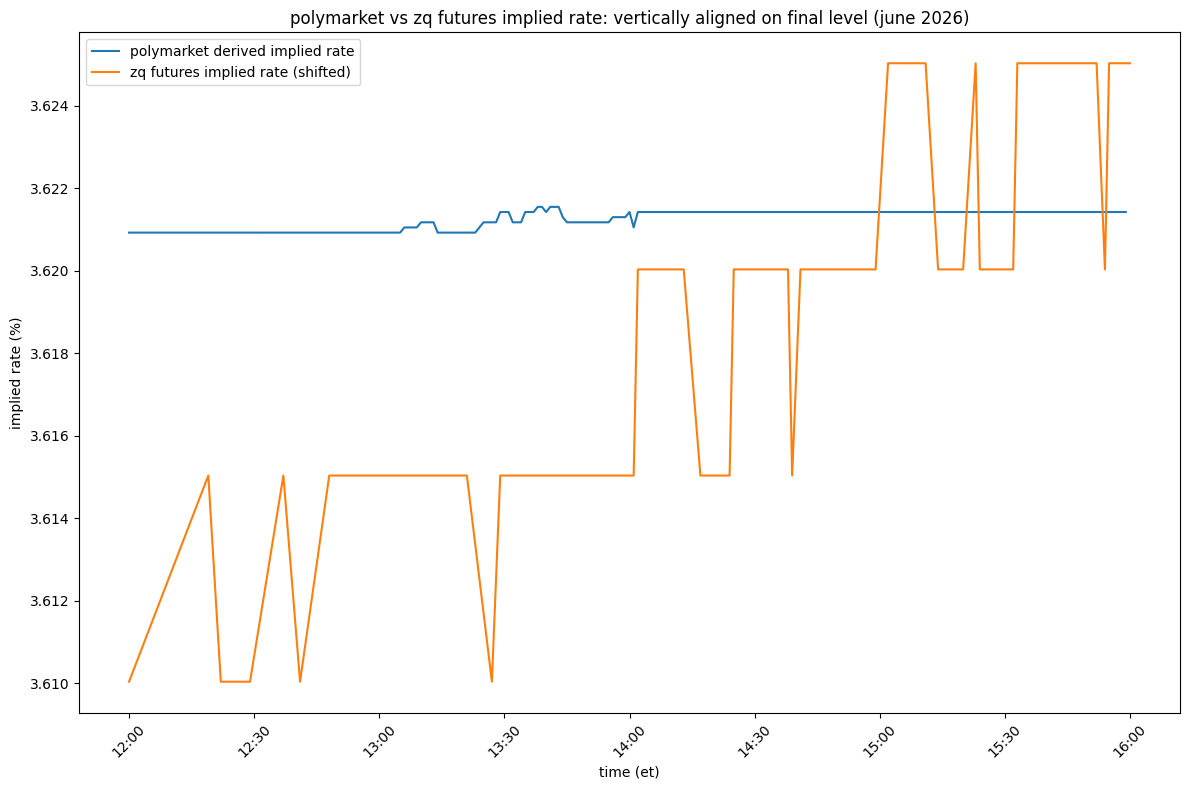

In [7]:
zq_final_june = june_zq_window[june_zq_window['datetime'] >= '2026-06-17 14:00:00']['implied_rate'].mean()
poly_final_june = combined_june[combined_june.index >= '2026-06-17 14:00:00']['r_after'].mean()
shift_june = poly_final_june - zq_final_june
june_zq_window['implied_rate_shifted'] = june_zq_window['implied_rate'] + shift_june

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(combined_june.index, combined_june['r_after'], label='polymarket derived implied rate', color='tab:blue')
ax.plot(june_zq_window['datetime'], june_zq_window['implied_rate_shifted'], label='zq futures implied rate (shifted)', color='tab:orange')
ax.set_title('polymarket vs zq futures implied rate: vertically aligned on final level (june 2026)')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=june_zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

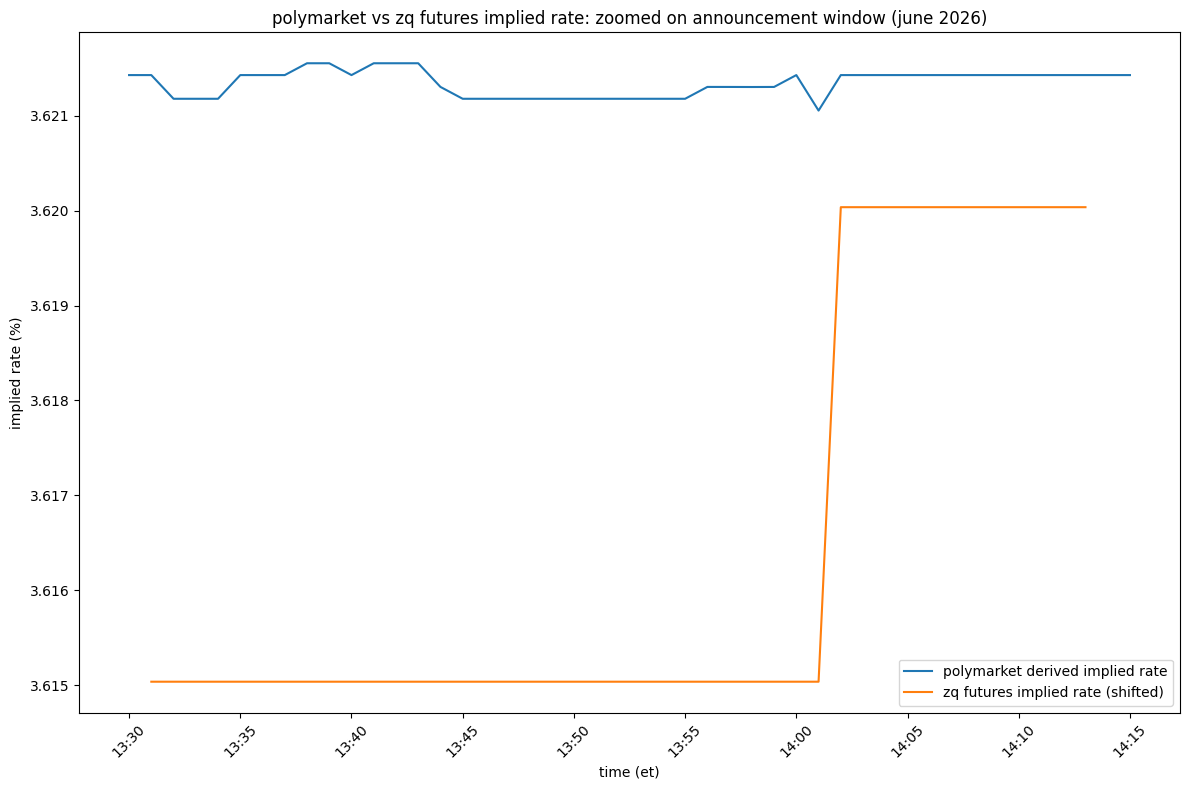

In [8]:
zoom_start_june = '2026-06-17 13:30:00'
zoom_end_june = '2026-06-17 14:15:00'

combined_zoom_june = combined_june[(combined_june.index >= zoom_start_june) & (combined_june.index <= zoom_end_june)]
zq_zoom_june = june_zq_window[(june_zq_window['datetime'] >= zoom_start_june) & (june_zq_window['datetime'] <= zoom_end_june)]

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(combined_zoom_june.index, combined_zoom_june['r_after'], label='polymarket derived implied rate', color='tab:blue')
ax.plot(zq_zoom_june['datetime'], zq_zoom_june['implied_rate_shifted'], label='zq futures implied rate (shifted)', color='tab:orange')
ax.set_title('polymarket vs zq futures implied rate: zoomed on announcement window (june 2026)')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=june_zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
pre_window_june = combined_june[(combined_june.index >= '2026-06-17 13:40:00') & (combined_june.index <= '2026-06-17 13:58:00')]
poly_diff_pre_june = pre_window_june['r_after'].diff()

zq_pre_june = june_zq_window[(june_zq_window['datetime'] >= '2026-06-17 13:40:00') & (june_zq_window['datetime'] <= '2026-06-17 13:58:00')]
zq_diff_pre_june = zq_pre_june.set_index('datetime')['implied_rate'].diff()

print("polymarket real moves:")
print(poly_diff_pre_june[poly_diff_pre_june != 0].dropna())
print("\nzq real moves:")
print(zq_diff_pre_june[zq_diff_pre_june != 0].dropna())

polymarket real moves:
datetime
2026-06-17 13:41:00-04:00    1.246261e-04
2026-06-17 13:44:00-04:00   -2.493766e-04
2026-06-17 13:45:00-04:00   -1.248751e-04
2026-06-17 13:56:00-04:00    1.248751e-04
2026-06-17 13:57:00-04:00   -2.495010e-07
2026-06-17 13:58:00-04:00   -6.913022e-07
Name: r_after, dtype: float64

zq real moves:
Series([], Name: implied_rate, dtype: float64)
